# Stratify `y` vs Stratify `both` — comparison

Compares the two cross-validation stratification strategies side-by-side using the
saved benchmark CSVs (one row per `dataset × method × classifier`, with metrics
already averaged across the 5 folds).

**Question.** Does switching from label-only stratification (`y`) to joint
label + sensitive-attribute (`both`) change the headline numbers, and does it
reorder which method 'wins'?

**Method.** Two views:
1. **Magnitude** of the shift — `delta = both − y` per cell, summarized per metric.
2. **Ranking stability** — Spearman correlation between the two strats' method-rankings,
   per `(dataset, classifier, metric)` triple.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

ROOT = Path('..') / 'outputs' / 'real_datasets'
y_csv     = ROOT / 'y_stratification.csv'
joint_csv = ROOT / 'joint_stratification.csv'

df_y     = pd.read_csv(y_csv)
df_joint = pd.read_csv(joint_csv)

PERF = ['accuracy', 'balanced_accuracy', 'precision', 'recall', 'f1_score']
FAIR = ['disparate_impact', 'spd', 'eod', 'aod',
        'true_negative_rate_difference', 'predictive_equality',
        'accuracy_parity', 'equal_opportunity_ratio',
        'false_negative_rate_difference']
ALL_METRICS = PERF + FAIR
HEADLINE    = ['accuracy', 'balanced_accuracy', 'f1_score',
               'disparate_impact', 'spd', 'eod', 'aod']
KEYS = ['dataset', 'method', 'classifier']

merged = df_y.merge(df_joint, on=KEYS, suffixes=('_y', '_joint'))
delta = merged[KEYS].copy()
for m in ALL_METRICS:
    delta[m] = merged[f'{m}_joint'] - merged[f'{m}_y']

print(f'merged shape: {merged.shape} (expected {len(df_y)} rows)')
delta.head()

merged shape: (240, 31) (expected 240 rows)


,dataset,method,classifier,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
0,Adult,Baseline,LogReg,-0.000307,-0.000421,-0.000785,-0.000639,-0.000666,-0.002979,-0.000879,-0.003263,-0.002028,0.000794,-0.005869,0.000317,-0.005870,0.003263
1,Adult,Baseline,DecisionTree,-0.002242,-0.001739,-0.005891,-0.000768,-0.003214,0.018751,0.005207,0.043608,0.020774,0.002061,0.001806,0.010401,0.070756,-0.043608
2,Adult,Baseline,SVC,0.000123,0.001038,-0.001338,0.002804,0.001254,-0.001049,-0.001393,-0.009558,-0.004635,-0.000289,0.009489,-0.002889,-0.015186,0.009558
3,Adult,Baseline,XGBoost,-0.000553,-0.001583,0.000264,-0.003571,-0.002006,0.007599,0.003592,0.007586,0.004938,-0.002290,0.015919,-0.000055,0.010485,-0.007586
4,Adult,FairSmote,LogReg,0.000246,0.000379,0.000388,0.000637,0.000469,-0.003004,-0.001542,-0.000908,-0.001256,0.001604,-0.006012,0.001285,-0.000788,0.000908


## 1. Per-metric shift — full table (14 metrics)

Aggregated across all 240 cells (5 datasets × 12 methods × 4 classifiers).
Signed view: direction matters more than magnitude here.

- **mean_delta** — net direction (does `both` systematically push the metric up or down?)
- **median_delta** — robust central tendency (less swayed by outliers)
- **pct_negative / pct_positive** — fraction of the 240 cells where `both` reports a lower / higher value than `y`
- **max_abs_delta** — worst-case shift on any single cell (the only |·| stat we keep, since "how big can it get?" is a useful tail question)

In [2]:
summary_full = pd.DataFrame({
    'mean_delta':    delta[ALL_METRICS].mean(),
    'median_delta':  delta[ALL_METRICS].median(),
    'pct_negative':  (delta[ALL_METRICS] < 0).mean() * 100,
    'pct_positive':  (delta[ALL_METRICS] > 0).mean() * 100,
    'max_abs_delta': delta[ALL_METRICS].abs().max(),
}).round(4)
summary_full

,mean_delta,median_delta,pct_negative,pct_positive,max_abs_delta
accuracy,-0.0017,0.0000,49.1667,46.6667,0.1272
balanced_accuracy,-0.0017,-0.0004,53.3333,45.8333,0.1409
precision,-0.0007,0.0003,47.0833,52.0833,0.2583
recall,-0.0061,-0.0004,51.2500,43.3333,0.2833
f1_score,-0.0042,-0.0006,52.5000,46.6667,0.2500
disparate_impact,-0.0140,-0.0013,52.5000,46.6667,0.5627
spd,-0.0058,-0.0009,51.6667,47.5000,0.3654
eod,-0.0132,-0.0044,60.4167,38.3333,0.4907
aod,-0.0078,-0.0023,56.6667,42.5000,0.3969
true_negative_rate_difference,0.0025,-0.0005,51.6667,47.5000,0.3522


### 1b. Is the shift real or just noise? — paired Wilcoxon

For each metric we ran a paired Wilcoxon signed-rank test of the 240 deltas against zero.
`wilcoxon_p < 0.05` means `both` produces values that are **systematically** different
from `y` — not just by chance. The cleanest answer to "is the direction real?".

In [3]:
from scipy.stats import wilcoxon

rows = []
for m in ALL_METRICS:
    d = delta[m].dropna()
    _, p = wilcoxon(d)
    rows.append({
        'mean_delta':   d.mean(),
        'median_delta': d.median(),
        'wilcoxon_p':   p,
        'significant':  p < 0.05,
    })
wilcoxon_df = pd.DataFrame(rows, index=ALL_METRICS).round(5)
wilcoxon_df

,mean_delta,median_delta,wilcoxon_p,significant
accuracy,-0.00171,0.00000,0.69835,False
balanced_accuracy,-0.00166,-0.00037,0.75807,False
precision,-0.00070,0.00028,0.09892,False
recall,-0.00614,-0.00041,0.02676,True
f1_score,-0.00416,-0.00057,0.28810,False
disparate_impact,-0.01396,-0.00129,0.01645,True
spd,-0.00583,-0.00091,0.06004,False
eod,-0.01320,-0.00440,0.00087,True
aod,-0.00783,-0.00227,0.01975,True
true_negative_rate_difference,0.00246,-0.00053,0.85485,False


## 2. Reduced headline view (7 metrics)

Same as above but limited to the metrics most people actually look at.

In [4]:
summary_full.loc[HEADLINE]

,mean_delta,median_delta,pct_negative,pct_positive,max_abs_delta
accuracy,-0.0017,0.0000,49.1667,46.6667,0.1272
balanced_accuracy,-0.0017,-0.0004,53.3333,45.8333,0.1409
f1_score,-0.0042,-0.0006,52.5000,46.6667,0.2500
disparate_impact,-0.0140,-0.0013,52.5000,46.6667,0.5627
spd,-0.0058,-0.0009,51.6667,47.5000,0.3654
eod,-0.0132,-0.0044,60.4167,38.3333,0.4907
aod,-0.0078,-0.0023,56.6667,42.5000,0.3969


## 3. Where the shift is largest — top movers (signed)

Two top-10 tables: cells where `both` shifts the headline metrics most **upward** (positive sum)
and most **downward** (negative sum). The split is more informative than "biggest |shift|"
because direction tells us whether `both` is making things look better or worse.

In [5]:
delta_with_score = delta.assign(
    signed_shift=delta[HEADLINE].sum(axis=1)
)

top_pos = (
    delta_with_score.nlargest(10, 'signed_shift')
    [KEYS + HEADLINE + ['signed_shift']]
    .round(4)
    .reset_index(drop=True)
)
top_neg = (
    delta_with_score.nsmallest(10, 'signed_shift')
    [KEYS + HEADLINE + ['signed_shift']]
    .round(4)
    .reset_index(drop=True)
)

print('Top 10 cells where `both` shifts headline metrics UPWARD:')
display(top_pos)
print('\nTop 10 cells where `both` shifts headline metrics DOWNWARD:')
display(top_neg)

Top 10 cells where `both` shifts headline metrics UPWARD:


,dataset,method,classifier,accuracy,balanced_accuracy,f1_score,disparate_impact,spd,eod,aod,signed_shift
0,Heart Disease,Baseline,DecisionTree,0.0333,0.0392,0.0150,0.4237,0.1518,0.1176,0.1385,0.9191
1,Heart Disease,Massaging,DecisionTree,0.0333,0.0392,0.0150,0.4237,0.1518,0.1176,0.1385,0.9191
2,Heart Disease,FAWOS,DecisionTree,0.0333,0.0392,0.0150,0.4237,0.1518,0.1176,0.1385,0.9191
3,Ricci,FairwayRemover,DecisionTree,-0.1272,-0.1409,-0.2500,0.2526,0.3654,0.3722,0.3297,0.8018
4,Heart Disease,FairMask,DecisionTree,0.0222,0.0275,0.0060,0.3450,0.1283,0.1022,0.1220,0.7532
5,Ricci,DisparateImpactRemover,XGBoost,0.0261,0.0237,0.0288,0.1323,0.0993,0.1501,0.1283,0.5886
6,Heart Disease,DisparateImpactRemover,DecisionTree,0.0000,0.0025,-0.0072,0.2898,0.0940,0.0848,0.0956,0.5595
7,Heart Disease,HeterogeneousFOS,DecisionTree,-0.0111,-0.0042,-0.0267,0.3346,0.0702,0.0473,0.1228,0.5330
8,Ricci,HeterogeneousFOS,DecisionTree,0.0087,0.0084,0.0128,0.1035,0.0975,0.1639,0.1053,0.5002
9,Ricci,DisparateImpactRemover,DecisionTree,-0.0409,-0.0432,-0.0440,0.1811,0.0923,0.1259,0.0706,0.3418



Top 10 cells where `both` shifts headline metrics DOWNWARD:


,dataset,method,classifier,accuracy,balanced_accuracy,f1_score,disparate_impact,spd,eod,aod,signed_shift
0,Ricci,LearningFairRepresentations,XGBoost,-0.1011,-0.1069,-0.1298,-0.3505,-0.2417,-0.4907,-0.3281,-1.7489
1,Ricci,LearningFairRepresentations,LogReg,-0.0678,-0.0664,-0.0348,-0.1816,-0.3262,-0.4417,-0.3969,-1.5152
2,Ricci,LearningFairRepresentations,DecisionTree,-0.1011,-0.1055,-0.1199,-0.2073,-0.1717,-0.4240,-0.2462,-1.3758
3,Ricci,HeterogeneousFOS,LogReg,-0.0500,-0.0499,-0.0384,-0.1750,-0.1047,-0.1683,-0.1587,-0.7449
4,Heart Disease,HeterogeneousFOS,XGBoost,0.0185,0.0167,0.0187,-0.3488,-0.1021,-0.1543,-0.1055,-0.6568
5,Heart Disease,LearningFairRepresentations,XGBoost,0.0111,0.0075,0.0137,-0.3235,-0.1011,-0.1254,-0.1085,-0.6261
6,Heart Disease,LearningFairRepresentations,LogReg,0.0185,0.0183,0.0200,-0.5627,-0.0076,-0.0438,-0.0125,-0.5697
7,Ricci,Massaging,DecisionTree,0.0014,-0.0000,-0.0029,-0.1726,-0.1252,-0.1168,-0.1433,-0.5595
8,Heart Disease,FairOversampling,DecisionTree,-0.0037,-0.0050,0.0000,-0.2568,-0.0851,-0.0900,-0.0955,-0.5361
9,Heart Disease,LearningFairRepresentations,DecisionTree,-0.0074,-0.0125,0.0056,-0.2461,-0.0849,-0.0760,-0.1049,-0.5263


## 4. Visual agreement — scatter (`y` on x-axis, `both` on y-axis)

Each dot is one `(dataset, method, classifier)` cell. The closer the cloud hugs the
diagonal, the more the two stratification strategies agree on that metric.

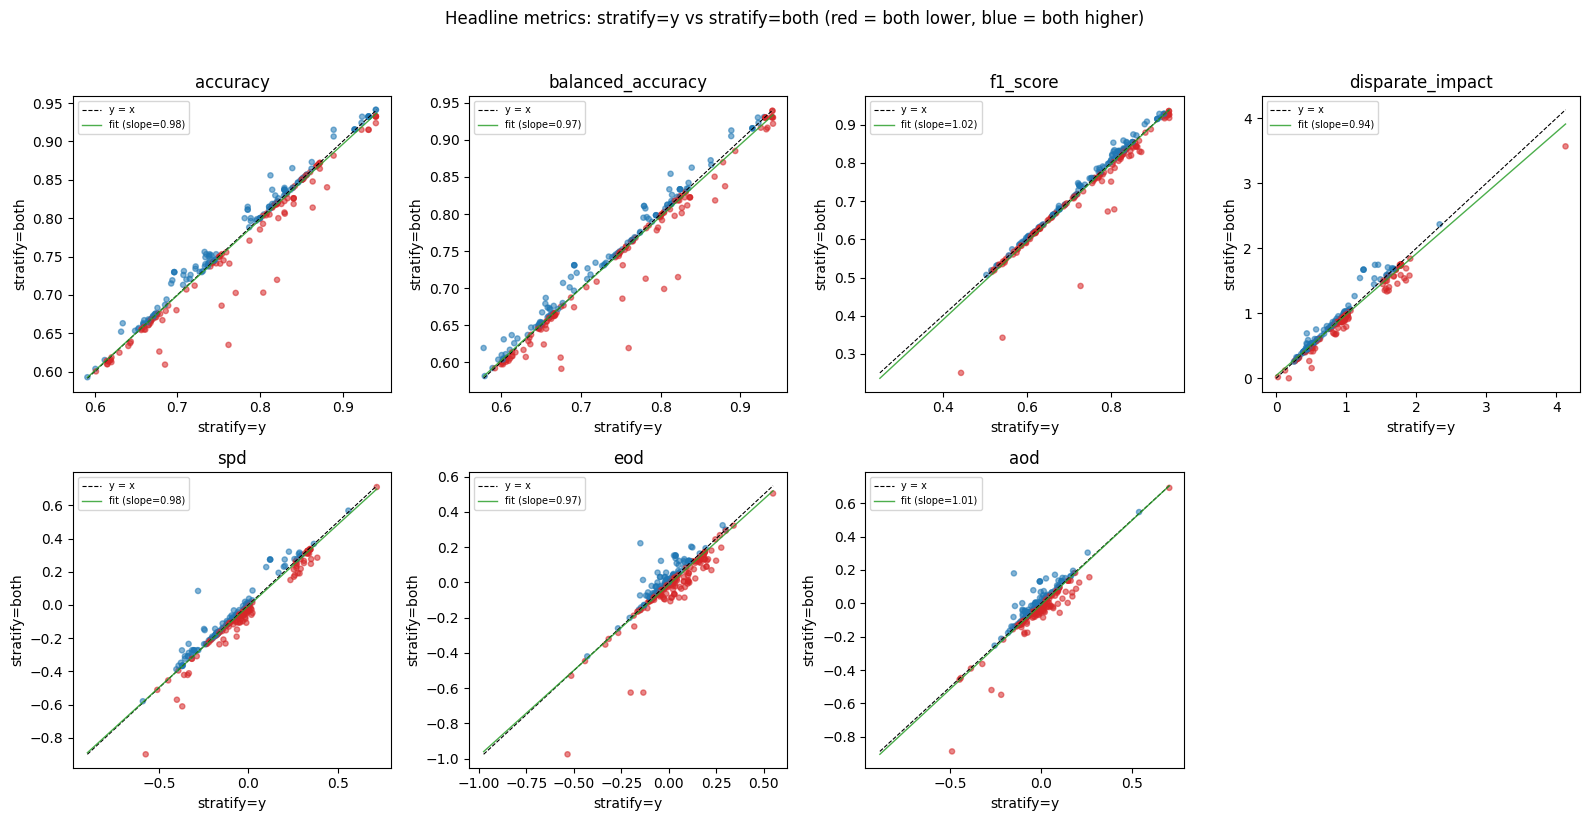

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()
for ax, m in zip(axes, HEADLINE):
    x = merged[f'{m}_y'].values
    y = merged[f'{m}_joint'].values
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    d = y - x
    colors = np.where(d < 0, 'tab:red', 'tab:blue')
    ax.scatter(x, y, s=14, alpha=0.55, c=colors)

    lo = float(np.min([x.min(), y.min()]))
    hi = float(np.max([x.max(), y.max()]))
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8, label='y = x')

    # Linear fit shows whether the cloud sits systematically above/below the diagonal
    coeffs = np.polyfit(x, y, 1)
    xs = np.linspace(lo, hi, 50)
    ax.plot(xs, np.polyval(coeffs, xs), color='tab:green',
            linewidth=1.0, alpha=0.85, label=f'fit (slope={coeffs[0]:.2f})')

    ax.set_title(m)
    ax.set_xlabel('stratify=y')
    ax.set_ylabel('stratify=both')
    ax.legend(loc='best', fontsize=7)
for ax in axes[len(HEADLINE):]:
    ax.axis('off')
fig.suptitle('Headline metrics: stratify=y vs stratify=both '
             '(red = both lower, blue = both higher)', y=1.02)
fig.tight_layout()
plt.show()

## 5. Ranking stability — Spearman correlation

For each `(dataset, classifier, metric)` we rank the 12 methods under each strategy
and compute Spearman's ρ between the two rankings. ρ ≈ 1 means the two strategies
agree on which method is best/worst; lower ρ means the choice of stratification
actively reorders the leaderboard.

We report mean and minimum ρ per metric (min is the worst-case `(dataset, classifier)` pair).

In [7]:
records = []
for (ds, clf), sub in merged.groupby(['dataset', 'classifier']):
    for m in ALL_METRICS:
        rho, _ = spearmanr(sub[f'{m}_y'], sub[f'{m}_joint'])
        records.append({
            'dataset': ds, 'classifier': clf, 'metric': m, 'spearman': rho,
        })
rank_df = pd.DataFrame(records)

rank_summary = (
    rank_df.groupby('metric')['spearman']
    .agg(['mean', 'min'])
    .round(3)
    .loc[ALL_METRICS]
)
rank_summary

,mean,min
metric,,
accuracy,0.792,-0.035
balanced_accuracy,0.752,0.068
precision,0.741,0.043
recall,0.837,-0.253
f1_score,0.806,0.028
disparate_impact,0.678,-0.496
spd,0.734,-0.394
eod,0.610,-0.358
aod,0.732,-0.220


In [8]:
# 10 (dataset, classifier, metric) triples where rankings disagree most
rank_df.nsmallest(10, 'spearman').reset_index(drop=True).round(3)

,dataset,classifier,metric,spearman
0,Heart Disease,XGBoost,accuracy_parity,-0.539
1,Heart Disease,DecisionTree,disparate_impact,-0.496
2,Heart Disease,DecisionTree,predictive_equality,-0.397
3,Heart Disease,DecisionTree,spd,-0.394
4,German,XGBoost,accuracy_parity,-0.392
5,Heart Disease,DecisionTree,eod,-0.358
6,Heart Disease,DecisionTree,false_negative_rate_difference,-0.358
7,Heart Disease,XGBoost,recall,-0.253
8,Heart Disease,DecisionTree,aod,-0.220
9,Heart Disease,DecisionTree,equal_opportunity_ratio,-0.151


## 5b. Where the drift lives — per-method, per-dataset, per-classifier (signed)

Mean signed delta on the 7 headline metrics, sliced three ways. Negative
values on a fairness metric mean `both` reports it lower (closer to "less fair");
positive means higher. Useful for spotting which methods, datasets, and classifiers
absorb the systematic drift.

In [9]:
m_long = delta.melt(id_vars=KEYS, value_vars=HEADLINE,
                    var_name='metric', value_name='delta')

per_method = (
    m_long.pivot_table(index='method', columns='metric',
                       values='delta', aggfunc='mean')[HEADLINE].round(4)
)
per_dataset = (
    m_long.pivot_table(index='dataset', columns='metric',
                       values='delta', aggfunc='mean')[HEADLINE].round(4)
)
per_classifier = (
    m_long.pivot_table(index='classifier', columns='metric',
                       values='delta', aggfunc='mean')[HEADLINE].round(4)
)

print('Per-method mean signed delta:')
display(per_method)
print('\nPer-dataset mean signed delta:')
display(per_dataset)
print('\nPer-classifier mean signed delta:')
display(per_classifier)

Per-method mean signed delta:


metric,accuracy,balanced_accuracy,f1_score,disparate_impact,spd,eod,aod
method,,,,,,,
Baseline,0.0019,0.0025,0.0006,0.0131,0.0027,-0.0054,0.0011
DisparateImpactRemover,-0.0018,-0.0012,-0.0018,0.0262,0.0133,0.0118,0.0129
FAWOS,-0.0015,-0.0015,-0.0022,0.0189,0.0092,0.0004,0.0076
FairBalanceClassifier,-0.0019,-0.0015,-0.0031,-0.0210,-0.0106,-0.0168,-0.0105
FairMask,0.0043,0.0049,0.0026,0.0049,-0.0008,-0.0082,-0.0018
FairOversampling,-0.0020,-0.0015,-0.0026,-0.0377,-0.0161,-0.0200,-0.0183
FairSmote,0.0032,0.0036,0.0021,-0.0346,-0.0133,-0.0112,-0.0053
FairwayRemover,-0.0069,-0.0095,-0.0232,0.0082,0.0232,0.0146,0.0153
HeterogeneousFOS,-0.0028,-0.0012,-0.0043,-0.0286,-0.0145,-0.0190,-0.0132



Per-dataset mean signed delta:


metric,accuracy,balanced_accuracy,f1_score,disparate_impact,spd,eod,aod
dataset,,,,,,,
Adult,-0.0003,-0.0001,-0.0003,0.0033,0.0008,0.0006,0.0006
Compas,-0.0012,-0.0012,-0.0013,0.0108,0.0048,0.0063,0.0039
German,0.0040,0.0044,0.0026,-0.0312,-0.0240,-0.0183,-0.0264
Heart Disease,0.0033,0.0050,-0.0011,-0.0311,-0.0061,-0.0267,0.0009
Ricci,-0.0150,-0.0170,-0.0214,-0.0218,-0.0045,-0.0285,-0.0187



Per-classifier mean signed delta:


metric,accuracy,balanced_accuracy,f1_score,disparate_impact,spd,eod,aod
classifier,,,,,,,
DecisionTree,-0.0028,-0.0025,-0.0065,0.0349,0.0164,0.0194,0.0107
LogReg,-0.0047,-0.0050,-0.0034,-0.0419,-0.0205,-0.0291,-0.0233
SVC,-0.0012,-0.0008,-0.0033,-0.0122,-0.0084,-0.0184,-0.0093
XGBoost,0.0018,0.0017,-0.0033,-0.0370,-0.0111,-0.0252,-0.0096


## 6. Per-method drift (signed)

Mean **signed** delta per method, averaged across datasets, classifiers, and the 7 headline metrics.
A bar far from zero on either side means the method's reported numbers shift *systematically*
when the strat changes — not just noisily. Two-sided so the outlier is obvious.

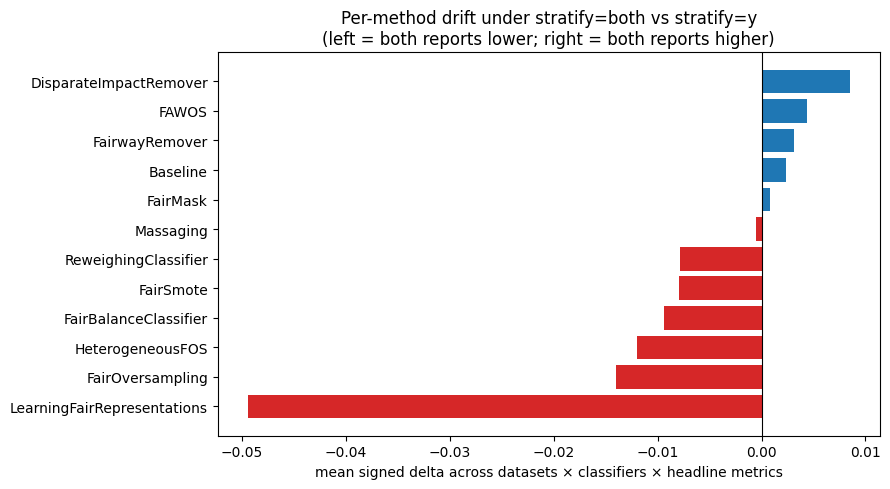

method
LearningFairRepresentations   -0.0495
FairOversampling              -0.0140
HeterogeneousFOS              -0.0120
FairBalanceClassifier         -0.0094
FairSmote                     -0.0079
ReweighingClassifier          -0.0078
Massaging                     -0.0005
FairMask                       0.0009
Baseline                       0.0023
FairwayRemover                 0.0031
FAWOS                          0.0044
DisparateImpactRemover         0.0085
Name: delta, dtype: float64

In [10]:
method_drift = (
    delta.melt(id_vars=KEYS, value_vars=HEADLINE,
               var_name='metric', value_name='delta')
    .groupby('method')['delta']
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['tab:red' if v < 0 else 'tab:blue' for v in method_drift.values]
ax.barh(method_drift.index, method_drift.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('mean signed delta across datasets × classifiers × headline metrics')
ax.set_title('Per-method drift under stratify=both vs stratify=y\n'
             '(left = both reports lower; right = both reports higher)')
fig.tight_layout()
plt.show()

method_drift.round(4)

## Takeaways

**Performance metrics are unaffected.** Mean shifts on `accuracy`, `balanced_accuracy`, `f1_score`,
`precision` are all < 0.005 in absolute value and **not** statistically significant
(Wilcoxon p > 0.05). The two strats agree on performance — pick either, you'll get the same numbers.

**Fairness metrics drift systematically toward "less fair."** Disparate impact (−0.014, p = 0.016),
EOD (−0.013, p = 0.001), AOD (−0.008, p = 0.020), accuracy_parity (−0.008, p = 0.003), and
equal_opportunity_ratio (−0.021, p = 0.001) all shift in the unfavorable direction under `both`.
Mirror image on FNR_difference (+0.013, p = 0.001). The shifts are small (~0.01–0.02 on average)
but consistent. Likely cause: under `y`-only strat, small test folds can land with a near-degenerate
group split, which masks disparities (no group → no disparity to measure). `both` enforces a balanced
group split per fold and exposes the real gap. **`both` reports slightly worse fairness — but more
honestly.**

**One method is unusually sensitive: `LearningFairRepresentations`.** Its mean signed shifts on
fairness are 5–10× larger than the next method (DI = −0.10, EOD = −0.08, AOD = −0.07, SPD = −0.05).
Under `y`, LFR looks meaningfully fairer than it actually is. Worth flagging in any results table or
paper that reports LFR numbers.

**Sensitivity is concentrated in small datasets.** Adult and Compas barely move (mean shifts
≤ 0.01 on every headline metric — the joint stratification happens by chance with ~30k rows).
German, Heart Disease, and especially Ricci show shifts up to 0.03. **Recommendation: use
`stratify=both` for small datasets at minimum.**

**Rankings mostly hold but fairness is shakier.** Spearman ρ on method rankings is 0.75–0.84 mean for
performance metrics, 0.53–0.73 for fairness. `accuracy_parity` is the least stable
(mean ρ = 0.53, min = −0.54). A handful of `(dataset, classifier)` cells reorder the leaderboard
completely (e.g. Heart Disease × DecisionTree on EOD), but they're the exception, not the rule.

**Practical conclusion.** `stratify=both` is the more honest default for fairness benchmarks,
particularly on small datasets. For large datasets the choice doesn't matter. The one method whose
conclusions could change with the strat choice is `LearningFairRepresentations`.